# Curvas dos melhores processos por objetivo

Este notebook recupera exatamente os `best_system_prompt` usados nas tabelas globais por objetivo
e mostra, para cada um deles, a evolução das métricas durante o processo de otimização.

A seleção segue o mesmo critério do notebook `plot_optimization_metric_tables_by_objective.ipynb`:
- para cada objetivo (`sep`, `etd`, `sep_etd_f1`);
- e para cada algoritmo;
- escolhe-se a configuração `with_optimization` com maior valor médio por usuário na própria métrica-alvo.

Para cada processo selecionado, o notebook exibe:
1. um resumo da configuração vencedora;
2. um gráfico focado na métrica-alvo;
3. um gráfico com a métrica-alvo e as demais métricas principais registradas por época (`SEP`, `ETD` e `SEP_ETD_F1`).


In [1]:
import os
import sys
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib")

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Markdown, display

def _is_project_root(candidate: Path) -> bool:
    return (candidate / "run_prompt_optimizer.py").exists() and (candidate / "out").exists()


def find_local_project_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if _is_project_root(candidate):
            return candidate

    descendant_hints = []
    for base in (start, *start.parents):
        descendant_hints.extend(
            [
                base / "prompt-optim-expl-rec" / "explainability-with-LLMs",
                base / "explainability-with-LLMs",
            ]
        )

    for candidate in descendant_hints:
        if _is_project_root(candidate):
            return candidate

    raise FileNotFoundError(
        "Não foi possível localizar a raiz de explainability-with-LLMs. "
        "Execute o notebook no projeto, em um subdiretório dele ou a partir da raiz do workspace."
    )

PROJECT_ROOT = find_local_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.utils.optimization_process_analysis import load_process_bundle

METRIC_COLOR_MAP = {
    "etd": "#1f77b4",
    "sep": "#ff7f0e",
    "sep_etd_f1": "#2ca02c",
    "geom_mean": "#d62728",
    "mean_balance": "#8c564b",
}


def metric_color(metric_name: str | None, default: str = "#4C78A8") -> str:
    return METRIC_COLOR_MAP.get(str(metric_name), default)


METRIC_LABEL_MAP = {
    "etd": "ETD",
    "sep": "SEP",
    "sep_etd_f1": "SEP_ETD_F1",
    "geom_mean": "Geométrica",
    "mean_balance": "Mean Balance",
}


def metric_label(metric_name: str | None) -> str:
    return METRIC_LABEL_MAP.get(str(metric_name), str(metric_name))


def blend_with_white(color: str, blend: float) -> str:
    red, green, blue = mcolors.to_rgb(color)
    return mcolors.to_hex(
        tuple((1 - blend) * channel + blend for channel in (red, green, blue))
    )


def metric_shades(metric_name: str | None, size: int) -> list[str]:
    base_color = metric_color(metric_name)
    if size <= 1:
        return [base_color]

    max_blend = 0.45
    return [
        blend_with_white(base_color, max_blend * (index / max(1, size - 1)))
        for index in range(size)
    ]


def ensure_balance_metrics(epochs_df: pd.DataFrame) -> pd.DataFrame:
    epochs_df = epochs_df.copy()

    for split in ("train", "val"):
        sep_col = f"{split}_score_sep"
        etd_col = f"{split}_score_etd"

        if sep_col not in epochs_df.columns or etd_col not in epochs_df.columns:
            continue

        sep_series = pd.to_numeric(epochs_df[sep_col], errors="coerce")
        etd_series = pd.to_numeric(epochs_df[etd_col], errors="coerce")

        epochs_df[f"{split}_score_geom_mean"] = (
            sep_series.clip(lower=0) * etd_series.clip(lower=0)
        ).pow(0.5)
        epochs_df[f"{split}_score_mean_balance"] = (
            ((sep_series + etd_series) / 2.0)
            * (1 - (sep_series - etd_series).abs())
        )

    return epochs_df


def preferred_metric_order(metric_names: list[str]) -> list[str]:
    preferred = ["sep", "etd", "sep_etd_f1", "geom_mean", "mean_balance"]
    ordered = [metric_name for metric_name in preferred if metric_name in metric_names]
    ordered.extend(metric_name for metric_name in metric_names if metric_name not in ordered)
    return ordered

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 160)
pd.set_option("display.max_columns", 50)


In [2]:
MODEL_NAME = "Llama3.1-I"
SUMMARY_CSV = PROJECT_ROOT / "out" / "statistical_analysis" / "common" / "per_user_run_summary.csv"

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SUMMARY_CSV: {SUMMARY_CSV}")


PROJECT_ROOT: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/origin/06_prompt-optimization/prompt-optim-expl-rec/explainability-with-LLMs
SUMMARY_CSV: /mnt/ssd/prenassi/OTIMIAZAO_RECOMENDACAO/pos_WebMedia/origin/06_prompt-optimization/prompt-optim-expl-rec/explainability-with-LLMs/out/statistical_analysis/common/per_user_run_summary.csv


In [3]:
OBJECTIVE_ORDER = ["sep", "etd", "sep_etd_f1"]
ALGORITHM_ORDER = ["user_knn", "item_knn", "bprmf", "ncf"]
TARGET_COLUMN_BY_OBJECTIVE = {
    "sep": "mean_sep_per_user",
    "etd": "mean_etd_per_user",
    "sep_etd_f1": "mean_sep_etd_f1_per_user",
}


def ordered_algorithms(values: list[str]) -> list[str]:
    ordered = [algorithm for algorithm in ALGORITHM_ORDER if algorithm in values]
    ordered.extend(sorted(algorithm for algorithm in values if algorithm not in ordered))
    return ordered


def load_summary(summary_csv: Path) -> pd.DataFrame:
    if not summary_csv.exists():
        raise FileNotFoundError(f"Resumo estatístico não encontrado em {summary_csv}")

    df = pd.read_csv(summary_csv)
    numeric_cols = [
        "mean_sep_per_user",
        "mean_etd_per_user",
        "mean_sep_etd_f1_per_user",
        "n_users",
    ]
    for column in numeric_cols:
        if column in df.columns:
            df[column] = pd.to_numeric(df[column], errors="coerce")
    return df


def format_repr_model(value: str | float | None) -> str:
    if value is None or pd.isna(value):
        return "-"
    return str(value).replace("repr_", "")


def format_lambda(value: str | float | None) -> str:
    if value is None or pd.isna(value):
        return "-"
    return str(value).replace("mmr_lambda_", "").replace("_", ".")


def build_process_dir_rel(row: pd.Series) -> str:
    return (
        "out/prompt_optimization/"
        + str(row["model"])
        + "/"
        + str(row["algorithm"])
        + "/"
        + str(row["metric"])
        + "/"
        + str(row["representation_model"])
        + "/"
        + str(row["early_stopping_tag"])
        + "/"
        + str(row["mmr_lambda_tag"])
        + "/"
        + str(row["mmr_pool_tag"])
        + "/"
        + str(row["model"])
        + "/prompt_opt/"
        + str(row["metric"])
    )


def pick_best_optimized_rows(summary_df: pd.DataFrame, objective_metric: str) -> pd.DataFrame:
    target_column = TARGET_COLUMN_BY_OBJECTIVE[objective_metric]
    frame = summary_df[
        (summary_df["run_type"] == "with_optimization")
        & (summary_df["metric"] == objective_metric)
    ].copy()

    if frame.empty:
        return frame

    frame = frame.sort_values(
        by=[
            "algorithm",
            target_column,
            "mean_sep_etd_f1_per_user",
            "mean_sep_per_user",
            "mean_etd_per_user",
            "run_label",
        ],
        ascending=[True, False, False, False, False, True],
        na_position="last",
    )
    frame = frame.drop_duplicates(subset=["algorithm"], keep="first").reset_index(drop=True)
    frame["process_dir_rel"] = frame.apply(build_process_dir_rel, axis=1)
    frame["representation_model_label"] = frame["representation_model"].apply(format_repr_model)
    frame["mmr_lambda_quality"] = frame["mmr_lambda_tag"].apply(format_lambda)
    frame["algorithm"] = pd.Categorical(
        frame["algorithm"],
        categories=ordered_algorithms(frame["algorithm"].dropna().astype(str).unique().tolist()),
        ordered=True,
    )
    return frame.sort_values("algorithm").reset_index(drop=True)


def draw_process_charts(bundle: dict, title_prefix: str = "") -> None:
    plt.close("all")
    epochs_df = ensure_balance_metrics(bundle["epochs_df"].copy())
    objective_metric = bundle["summary"]["objective_metric"]

    if epochs_df.empty:
        display(Markdown("> Nenhuma época foi registrada para este processo."))
        return

    available_primary_metrics = [
        metric_name
        for metric_name in ["sep", "etd", "sep_etd_f1"]
        if (
            f"train_score_{metric_name}" in epochs_df.columns
            or f"val_score_{metric_name}" in epochs_df.columns
        )
    ]
    all_metric_names = []
    for metric_name in [objective_metric, *available_primary_metrics]:
        if metric_name not in all_metric_names:
            all_metric_names.append(metric_name)

    metric_colors = {
        metric_name: metric_color(metric_name)
        for metric_name in all_metric_names
    }
    epoch_positions = epochs_df["epoch"].tolist()
    epoch_labels = [epoch + 1 for epoch in epoch_positions]
    best_train_epochs = epochs_df.loc[epochs_df["is_best_train_epoch"], "epoch"].tolist()
    best_val_epochs = epochs_df.loc[epochs_df["is_best_val_epoch"], "epoch"].tolist()
    shared_best_epochs = sorted(set(best_train_epochs) & set(best_val_epochs))
    train_only_epochs = [epoch for epoch in best_train_epochs if epoch not in shared_best_epochs]
    val_only_epochs = [epoch for epoch in best_val_epochs if epoch not in shared_best_epochs]

    display(Markdown(
        "Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; "
        "cinza = mesma época foi a melhor em treino e validação."
    ))

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(
        epochs_df["epoch"],
        epochs_df["train_metric"],
        marker="o",
        linewidth=2,
        linestyle="-",
        color=metric_colors[objective_metric],
        label=f"train::{objective_metric}",
    )
    if epochs_df["val_metric"].notna().any():
        ax.plot(
            epochs_df["epoch"],
            epochs_df["val_metric"],
            marker="o",
            linewidth=2,
            linestyle="--",
            color=metric_colors[objective_metric],
            label=f"val::{objective_metric}",
        )

    for epoch in train_only_epochs:
        ax.axvline(epoch, color="#7b2cbf", linestyle=":", linewidth=2, alpha=0.9)
    for epoch in val_only_epochs:
        ax.axvline(epoch, color="#e75480", linestyle=":", linewidth=2, alpha=0.9)
    for epoch in shared_best_epochs:
        ax.axvline(epoch, color="#6c757d", linestyle="-", linewidth=2.2, alpha=0.95)

    chart_title = f"{title_prefix} - métrica-alvo ({objective_metric})" if title_prefix else f"Métrica-alvo ({objective_metric})"
    ax.set_title(chart_title)
    ax.set_xlabel("época")
    ax.set_ylabel("score")
    ax.set_xticks(epoch_positions)
    ax.set_xticklabels(epoch_labels)
    ax.legend(loc="best")
    plt.tight_layout()
    plt.show()

    if all_metric_names:
        fig, ax = plt.subplots(figsize=(14, 6))
        for metric_name in all_metric_names:
            train_col = f"train_score_{metric_name}"
            val_col = f"val_score_{metric_name}"
            line_color = metric_colors[metric_name]

            if train_col in epochs_df.columns and epochs_df[train_col].notna().any():
                ax.plot(
                    epochs_df["epoch"],
                    epochs_df[train_col],
                    marker="o",
                    linewidth=1.8,
                    linestyle="-",
                    color=line_color,
                    label=f"train::{metric_name}",
                )
            if val_col in epochs_df.columns and epochs_df[val_col].notna().any():
                ax.plot(
                    epochs_df["epoch"],
                    epochs_df[val_col],
                    marker="o",
                    linewidth=1.8,
                    linestyle="--",
                    color=line_color,
                    label=f"val::{metric_name}",
                )

        chart_title = f"{title_prefix} - todas as métricas" if title_prefix else "Todas as métricas"
        ax.set_title(chart_title)
        ax.set_xlabel("época")
        ax.set_ylabel("score")
        ax.set_xticks(epoch_positions)
        ax.set_xticklabels(epoch_labels)
        ax.legend(loc="best", ncol=2)
        plt.tight_layout()
        plt.show()
    else:
        display(Markdown("Nenhuma métrica detalhada foi encontrada para este processo."))
    plt.close("all")


Este notebook usa os mesmos `best_system_prompt` selecionados nas tabelas globais por objetivo.

## Objetivo `sep`

### Configurações selecionadas

,algorithm,representation_model,mmr_lambda_quality,sep_value,etd_value,sep_etd_f1_value,process_dir_rel
0,user_knn,sbert,0.5,0.710932,0.701639,0.685187,out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep
1,item_knn,llm2vec,0.5,0.701002,0.663934,0.662004,out/prompt_optimization/Llama3.1-I/item_knn/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep
2,bprmf,llm2vec,0.0,0.711800,0.713934,0.694968,out/prompt_optimization/Llama3.1-I/bprmf/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep
3,ncf,sbert,0.5,0.730987,0.646721,0.664689,out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep


### user_knn | repr=sbert | lambda=0.5

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/user_knn/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep,sep,user_knn,sbert,0.5,4,0.687248,4,0.695115,train_and_validation


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

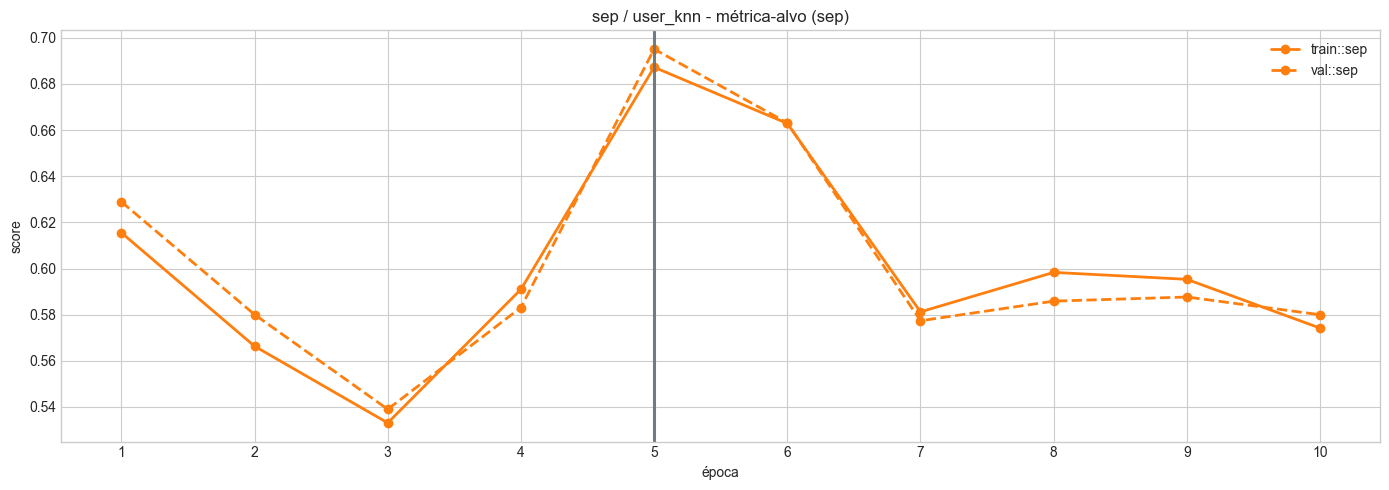

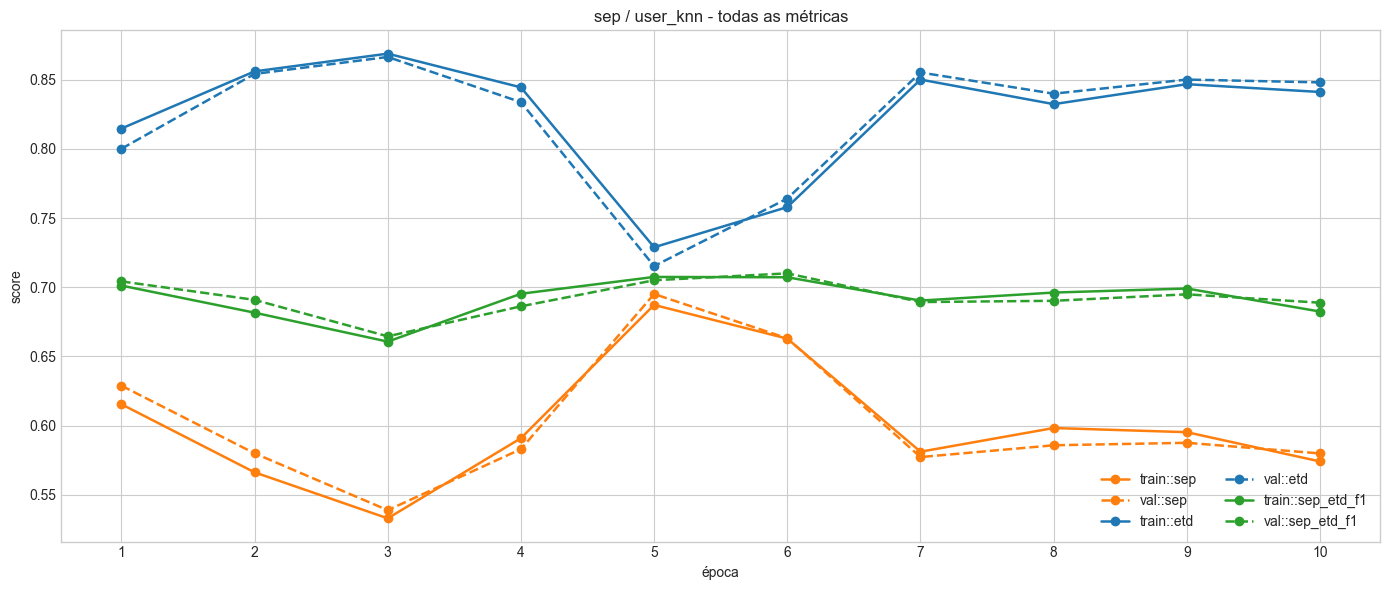

### item_knn | repr=llm2vec | lambda=0.5

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/item_knn/sep/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep,sep,item_knn,llm2vec,0.5,7,0.696605,7,0.69951,train_and_validation


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

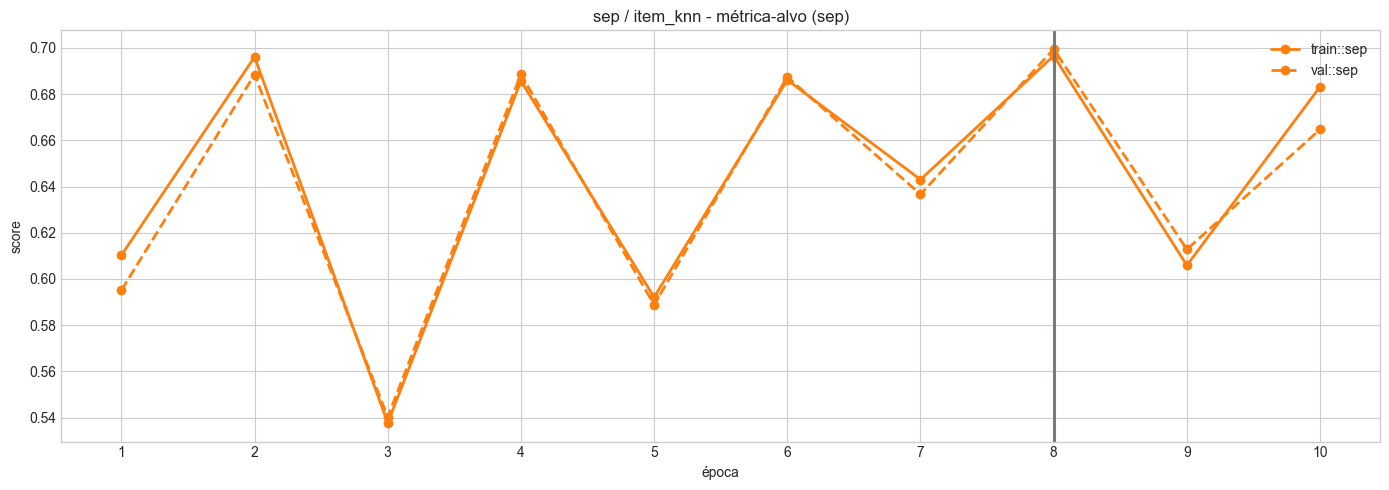

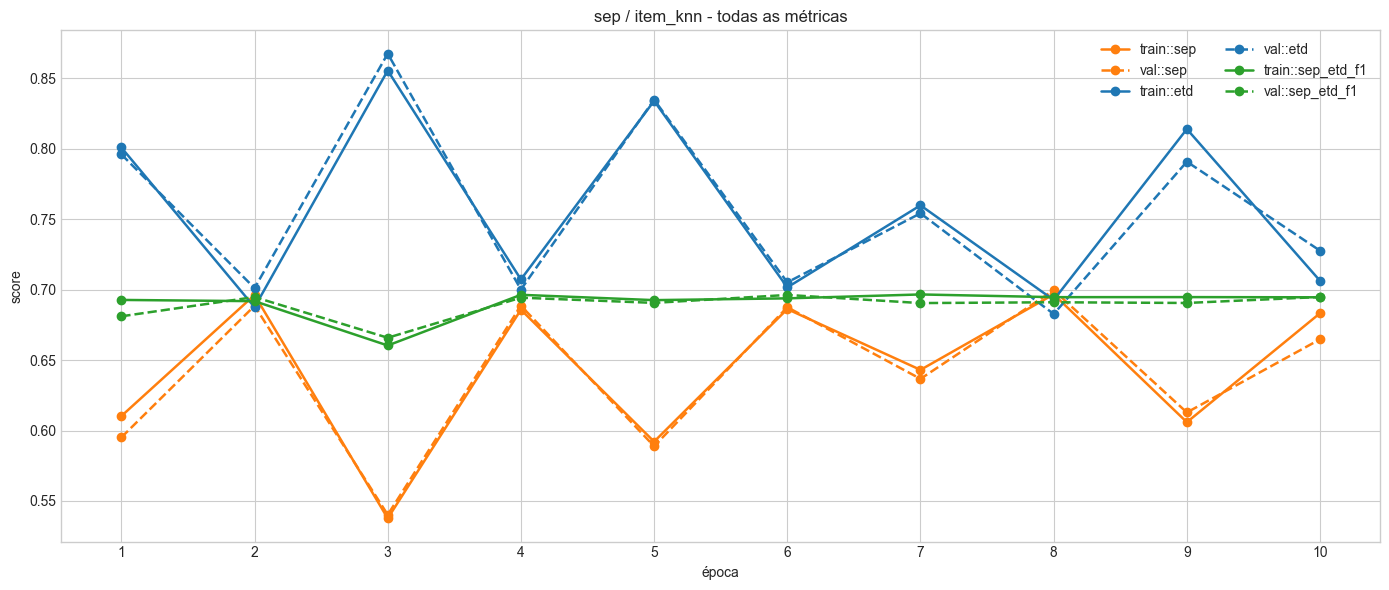

### bprmf | repr=llm2vec | lambda=0.0

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/bprmf/sep/repr_llm2vec/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep,sep,bprmf,llm2vec,0.0,2,0.713002,2,0.715061,train_and_validation


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

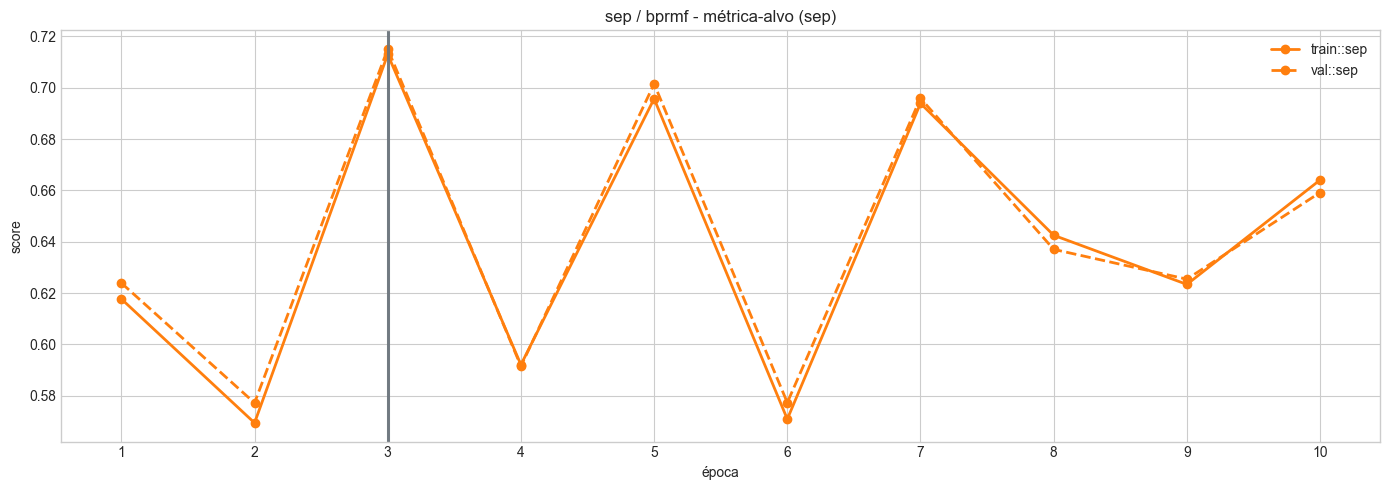

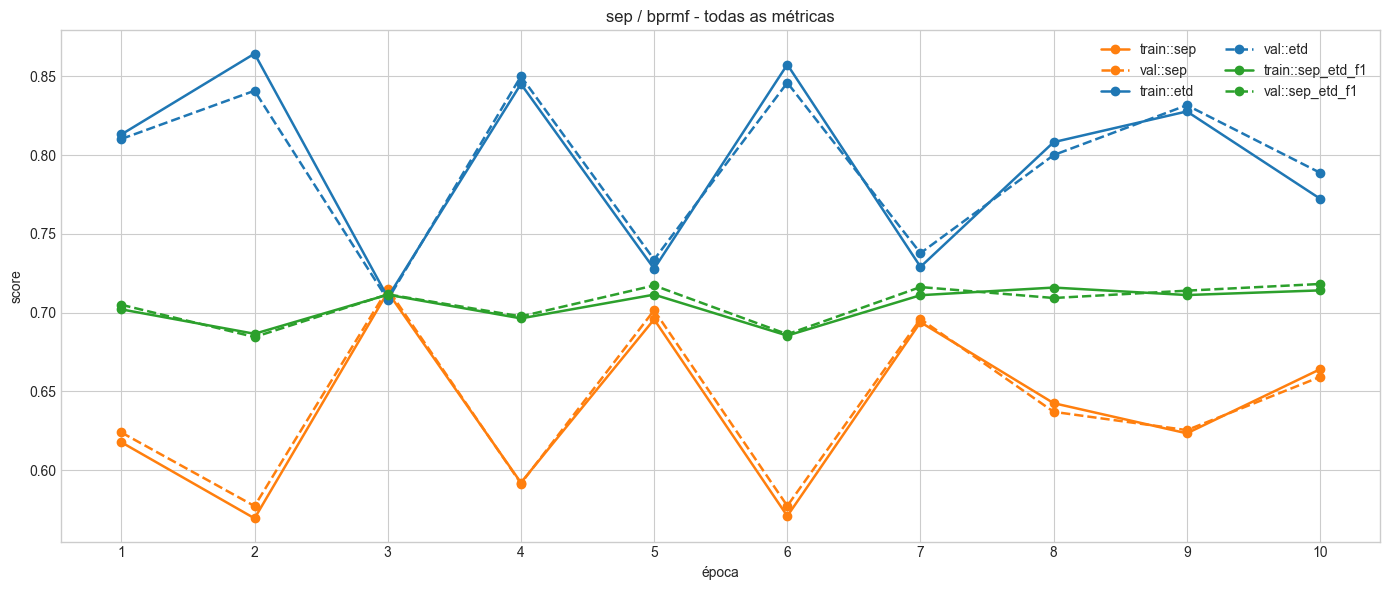

### ncf | repr=sbert | lambda=0.5

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/ncf/sep/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep,sep,ncf,sbert,0.5,9,0.720834,9,0.706445,train_and_validation


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

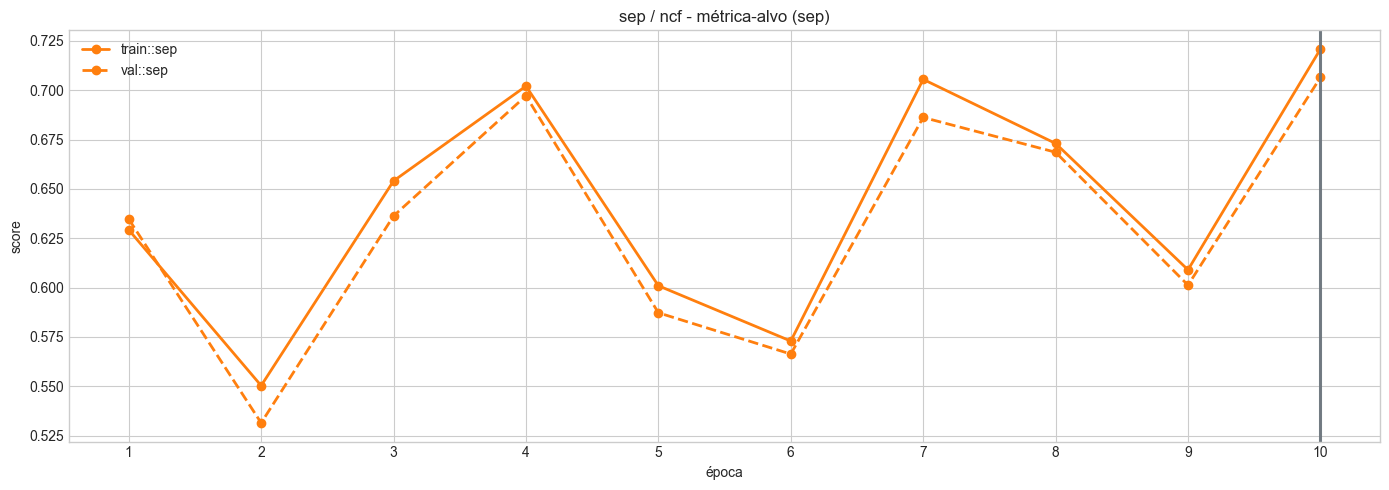

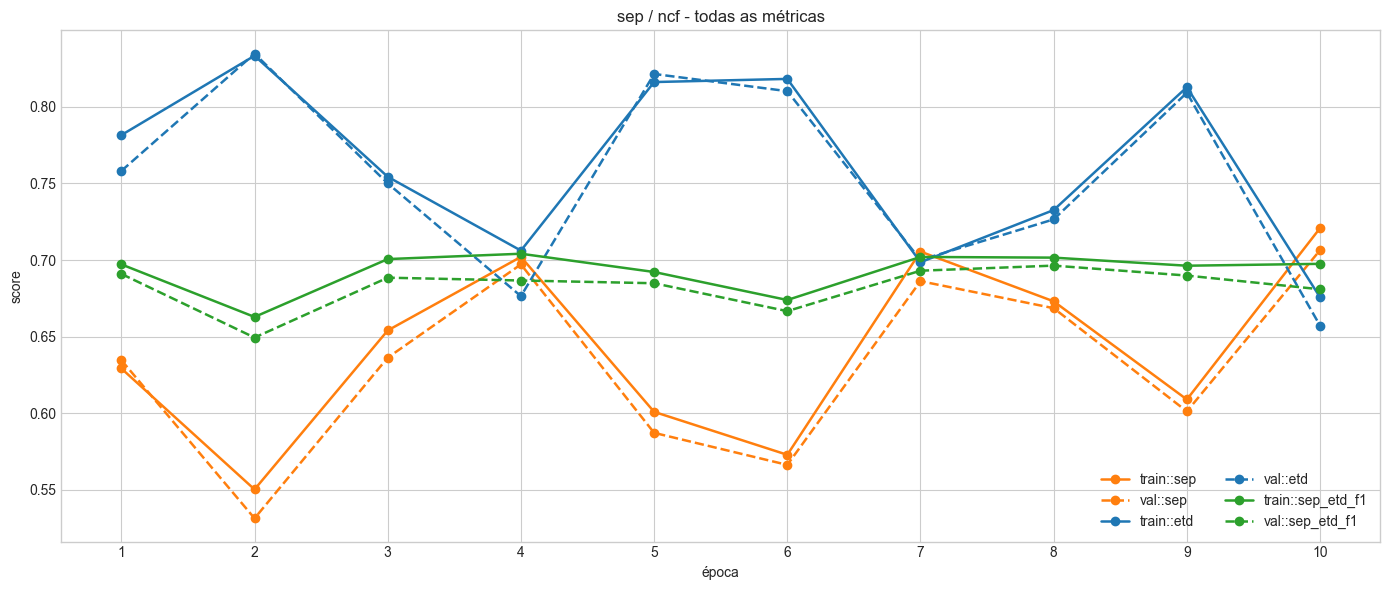

## Objetivo `etd`

### Configurações selecionadas

,algorithm,representation_model,mmr_lambda_quality,sep_value,etd_value,sep_etd_f1_value,process_dir_rel
0,user_knn,sbert,0.5,0.563554,0.835246,0.660217,out/prompt_optimization/Llama3.1-I/user_knn/etd/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/etd
1,item_knn,sbert,0.0,0.526633,0.851639,0.638445,out/prompt_optimization/Llama3.1-I/item_knn/etd/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/etd
2,bprmf,sbert,0.5,0.596044,0.848361,0.689403,out/prompt_optimization/Llama3.1-I/bprmf/etd/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/etd
3,ncf,llm2vec,1.0,0.555479,0.841803,0.656878,out/prompt_optimization/Llama3.1-I/ncf/etd/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/etd


### user_knn | repr=sbert | lambda=0.5

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/user_knn/etd/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/etd,etd,user_knn,sbert,0.5,5,0.846154,9,0.843878,train


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

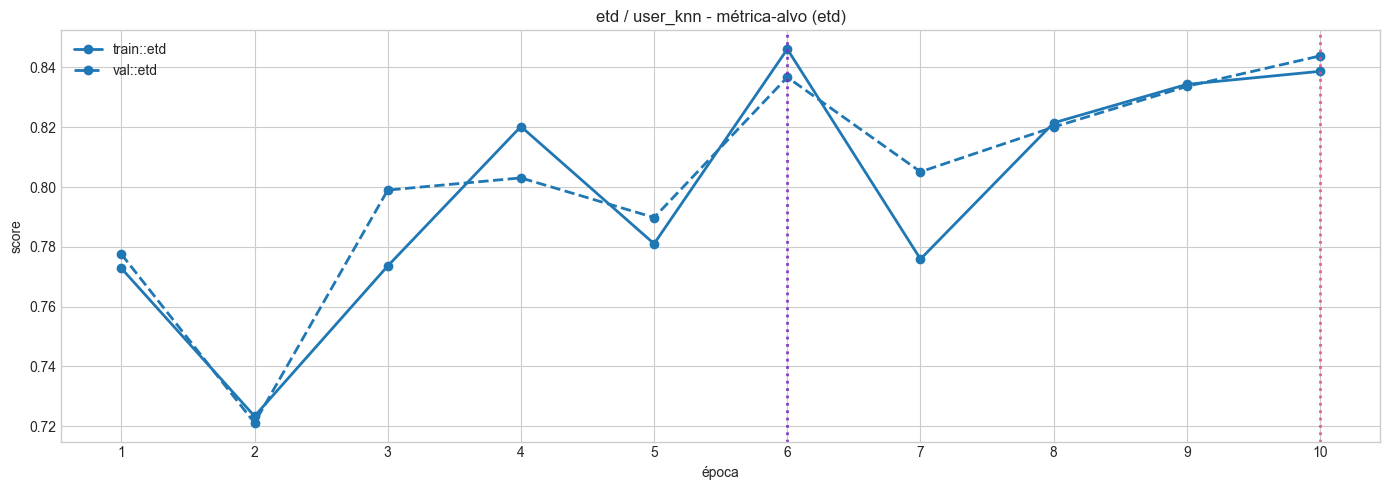

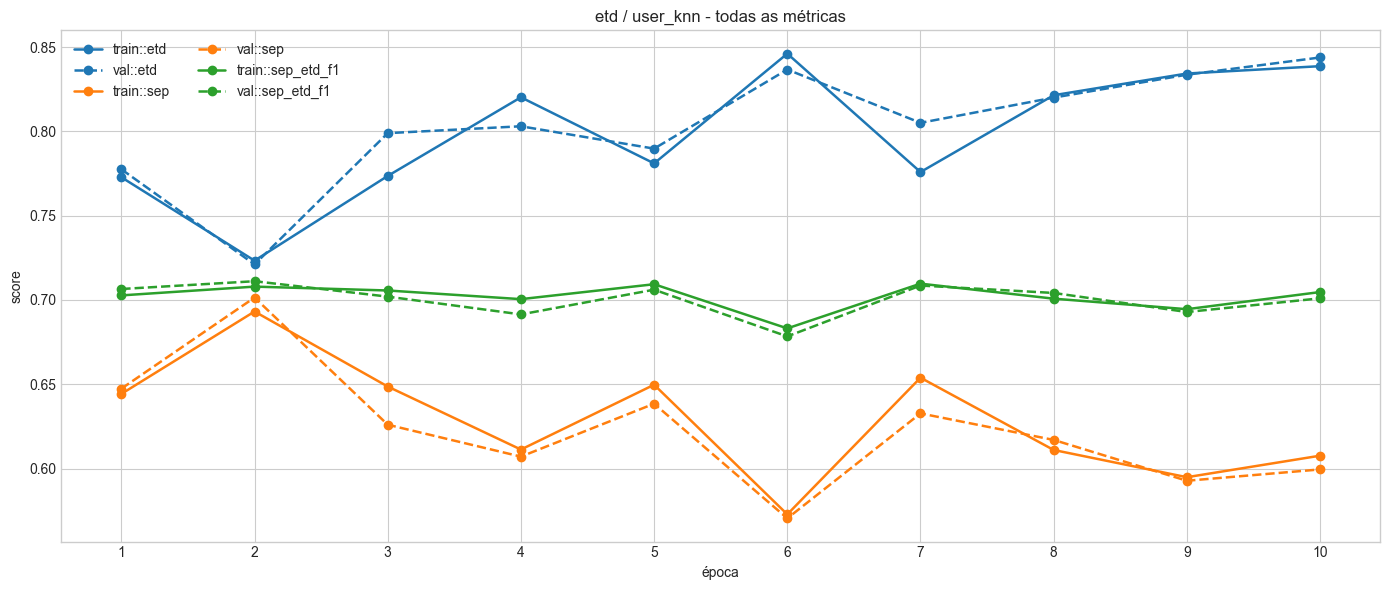

### item_knn | repr=sbert | lambda=0.0

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/item_knn/etd/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/etd,etd,item_knn,sbert,0.0,4,0.853077,4,0.846939,train_and_validation


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

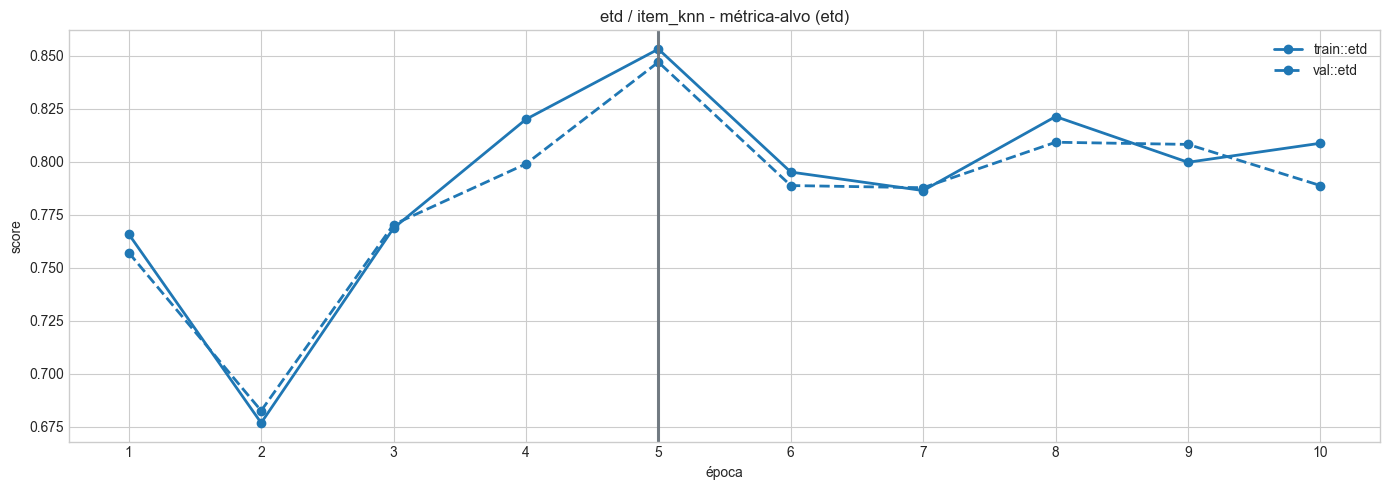

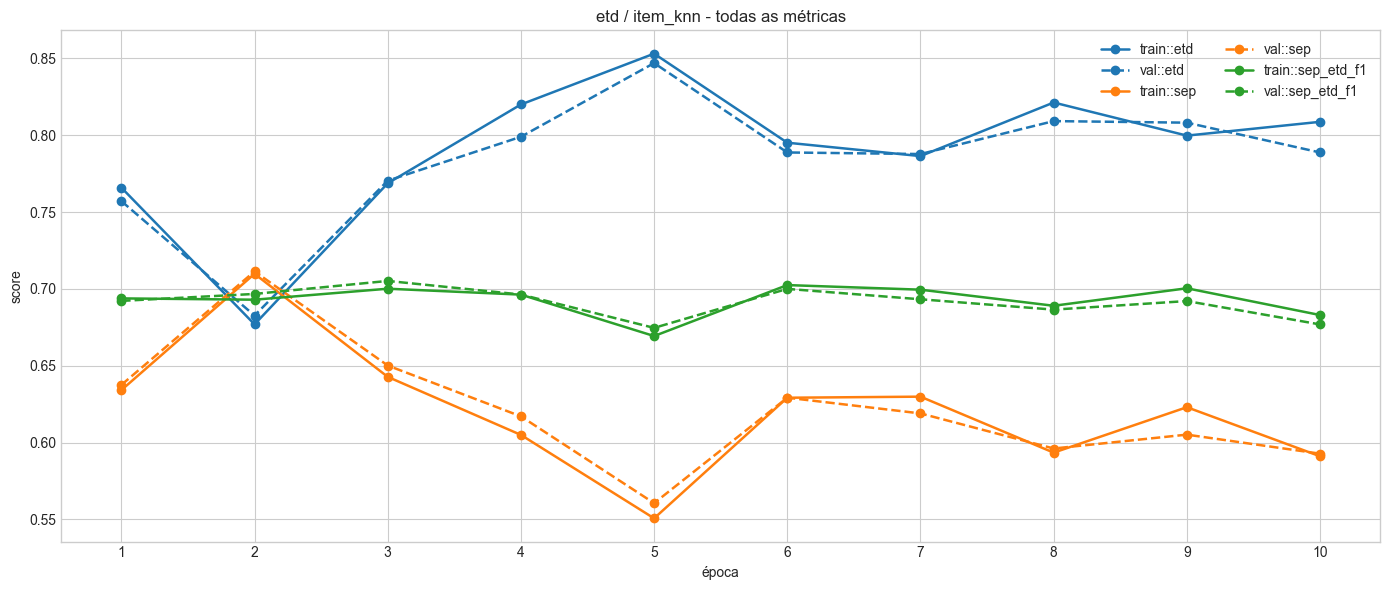

### bprmf | repr=sbert | lambda=0.5

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/bprmf/etd/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/etd,etd,bprmf,sbert,0.5,9,0.85,9,0.838776,train_and_validation


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

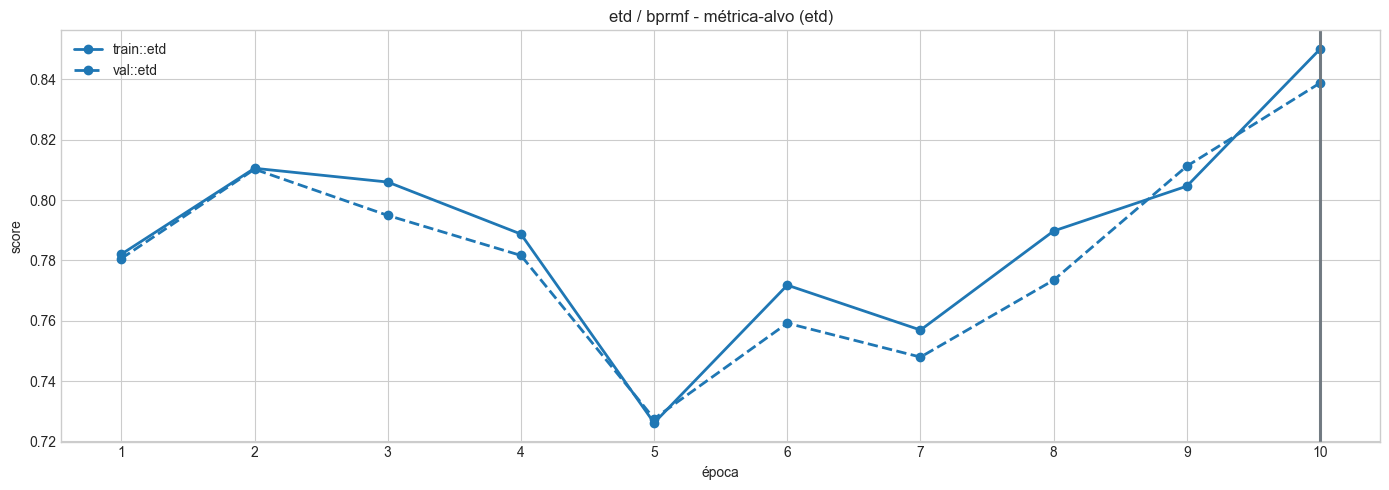

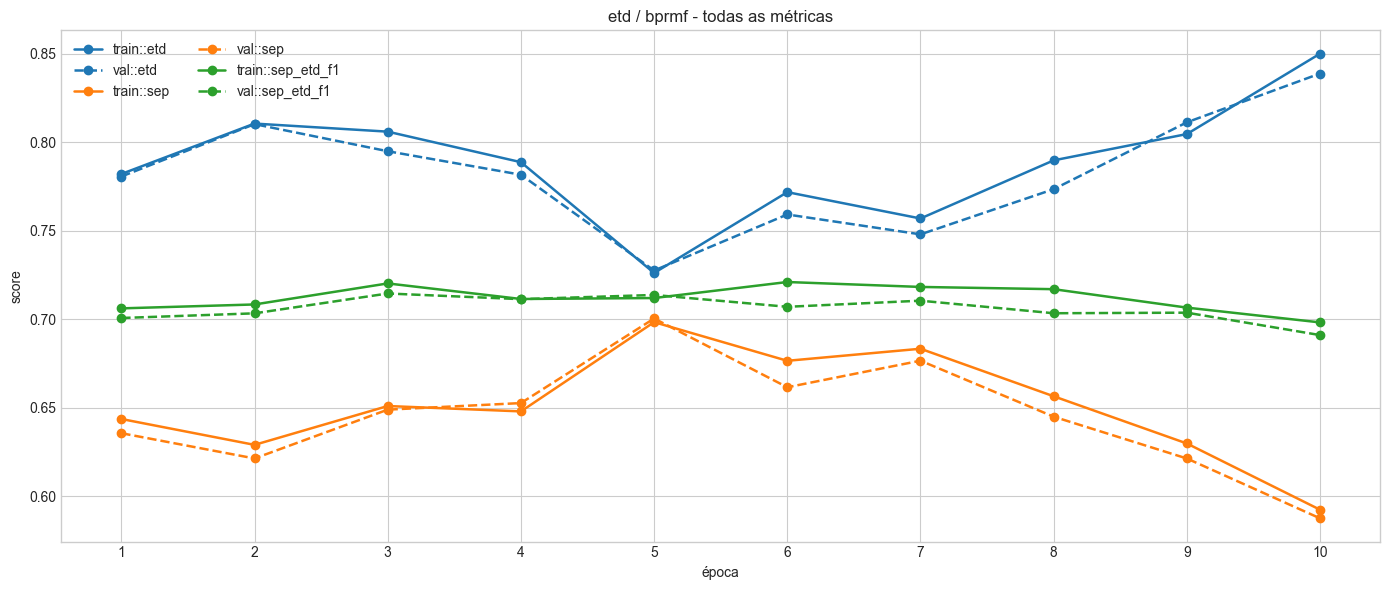

### ncf | repr=llm2vec | lambda=1.0

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/ncf/etd/repr_llm2vec/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/etd,etd,ncf,llm2vec,1.0,9,0.83,1,0.839796,train


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

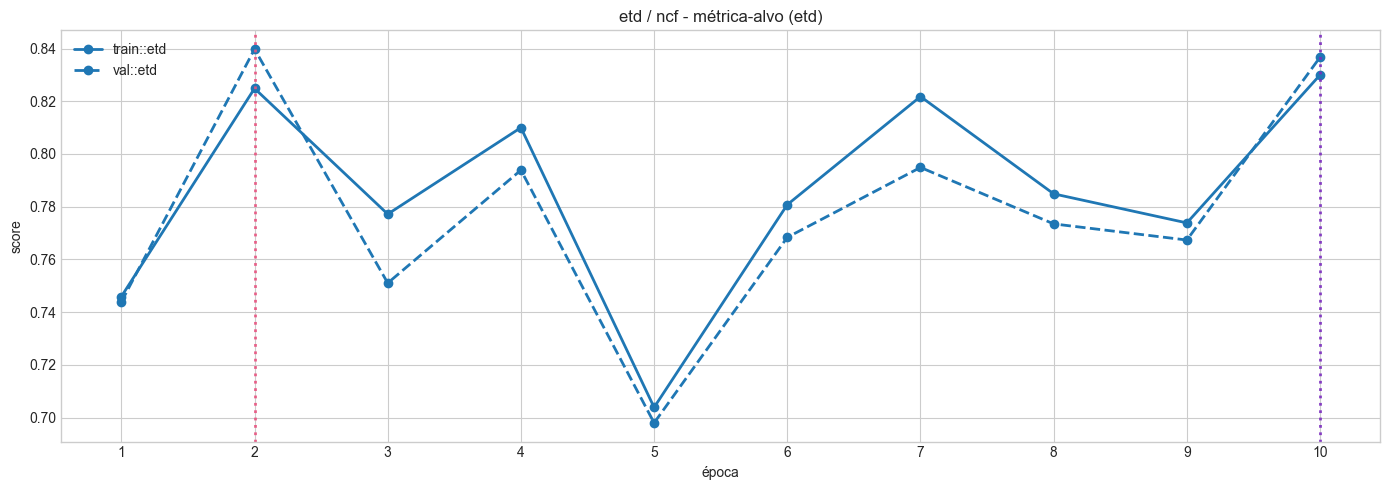

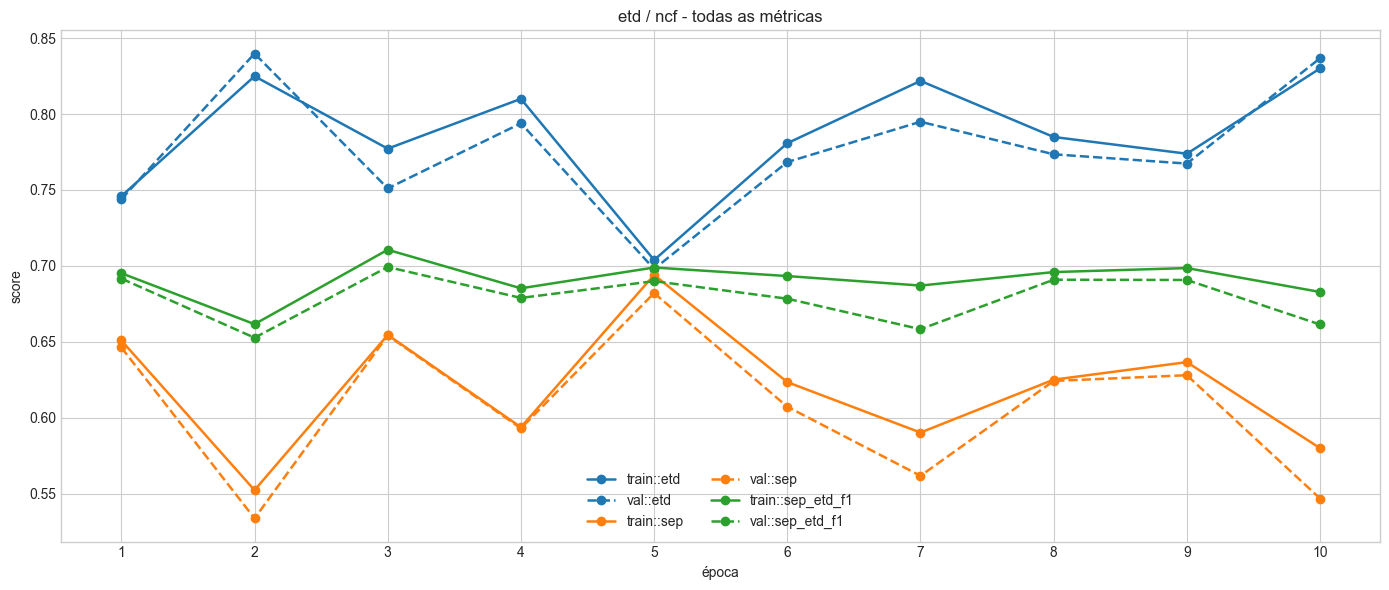

## Objetivo `sep_etd_f1`

### Configurações selecionadas

,algorithm,representation_model,mmr_lambda_quality,sep_value,etd_value,sep_etd_f1_value,process_dir_rel
0,user_knn,llm2vec,0.5,0.692547,0.748273,0.700532,out/prompt_optimization/Llama3.1-I/user_knn/sep_etd_f1/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1
1,item_knn,sbert,0.0,0.621315,0.795082,0.678642,out/prompt_optimization/Llama3.1-I/item_knn/sep_etd_f1/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1
2,bprmf,sbert,1.0,0.685957,0.771311,0.712135,out/prompt_optimization/Llama3.1-I/bprmf/sep_etd_f1/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1
3,ncf,sbert,0.5,0.619523,0.818852,0.691292,out/prompt_optimization/Llama3.1-I/ncf/sep_etd_f1/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1


### user_knn | repr=llm2vec | lambda=0.5

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/user_knn/sep_etd_f1/repr_llm2vec/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1,sep_etd_f1,user_knn,llm2vec,0.5,6,0.721036,7,0.721365,train


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

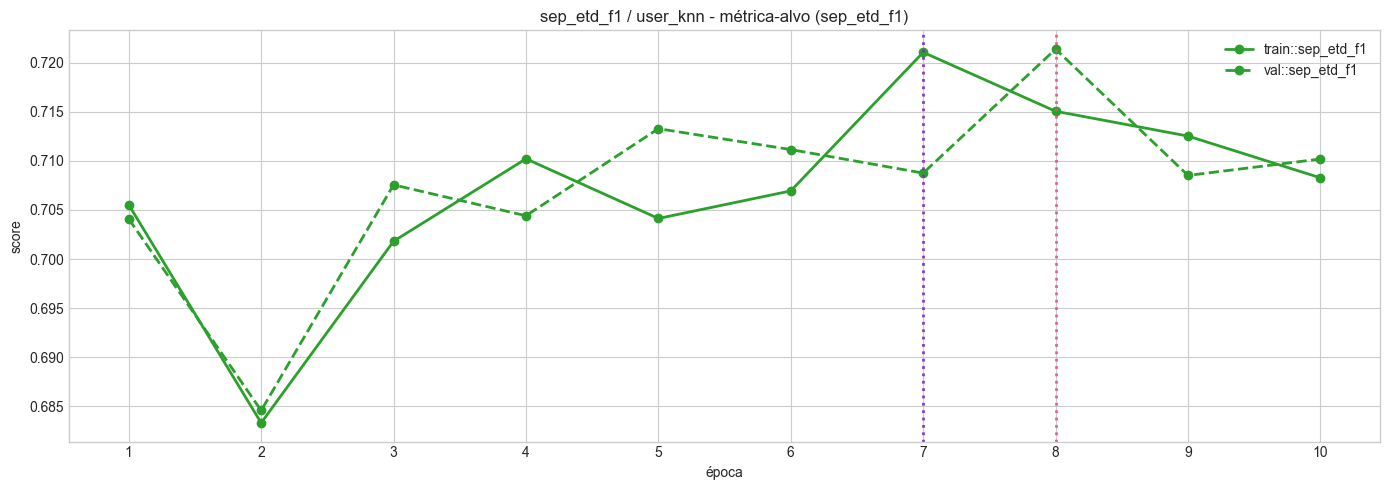

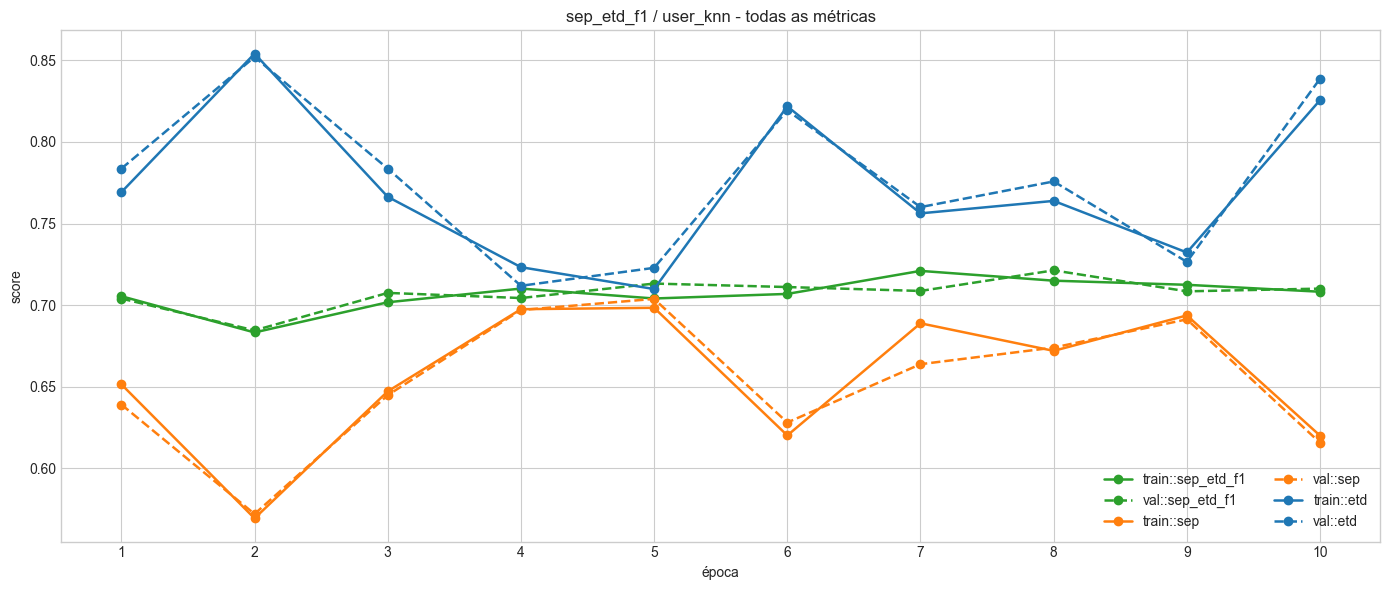

### item_knn | repr=sbert | lambda=0.0

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/item_knn/sep_etd_f1/repr_sbert/early_false/mmr_lambda_0_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1,sep_etd_f1,item_knn,sbert,0.0,6,0.706976,6,0.710105,train_and_validation


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

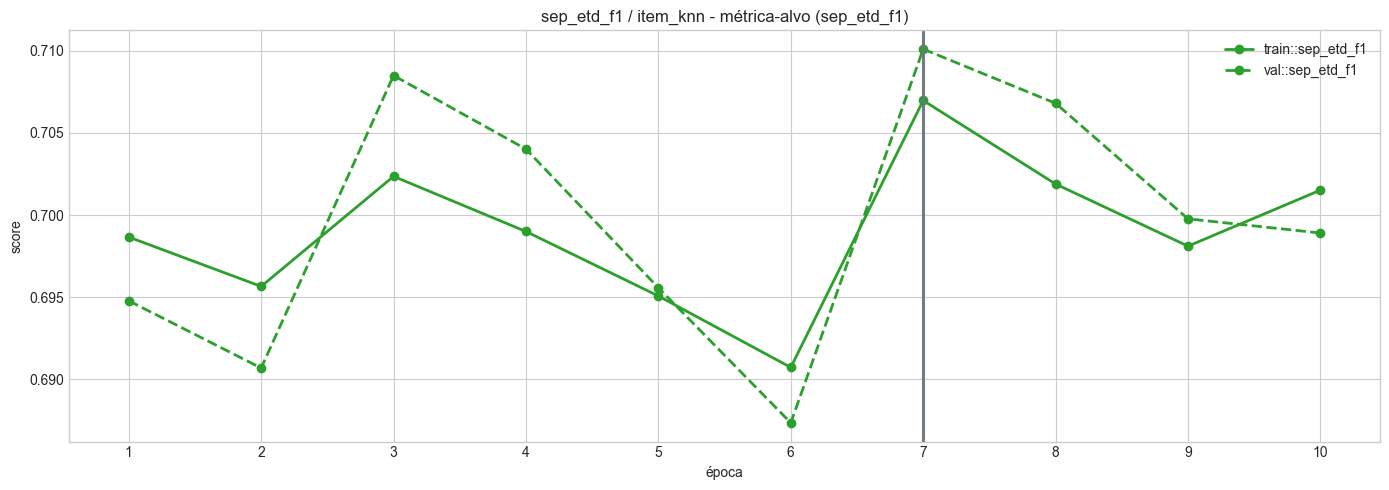

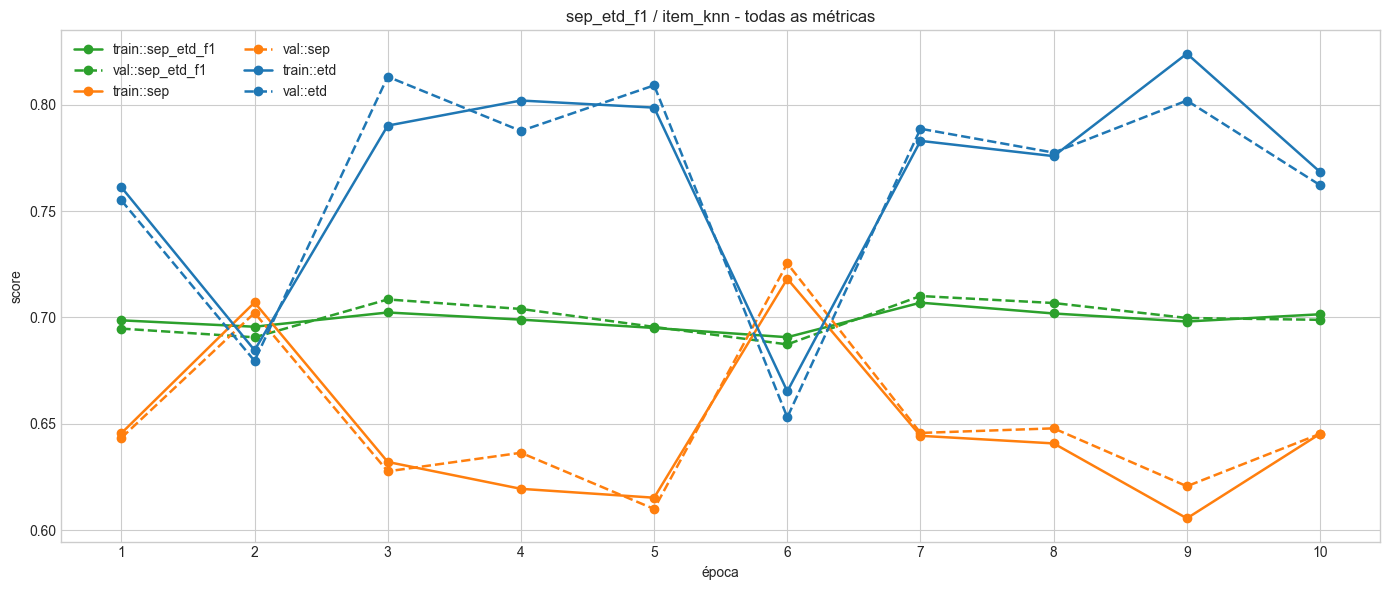

### bprmf | repr=sbert | lambda=1.0

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/bprmf/sep_etd_f1/repr_sbert/early_false/mmr_lambda_1_0/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1,sep_etd_f1,bprmf,sbert,1.0,7,0.72479,4,0.717464,train


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

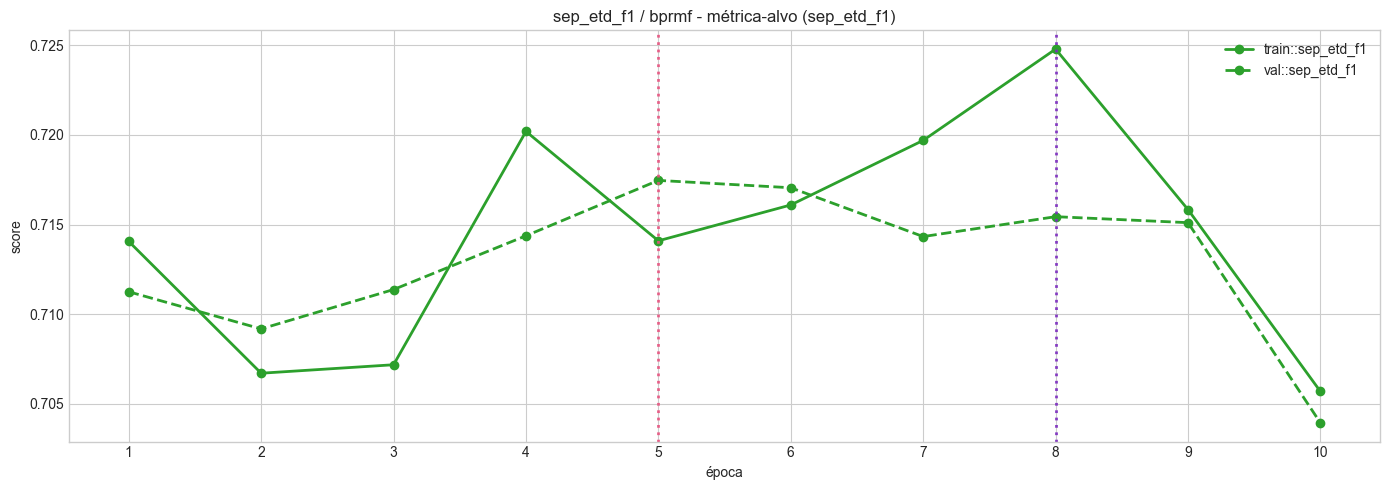

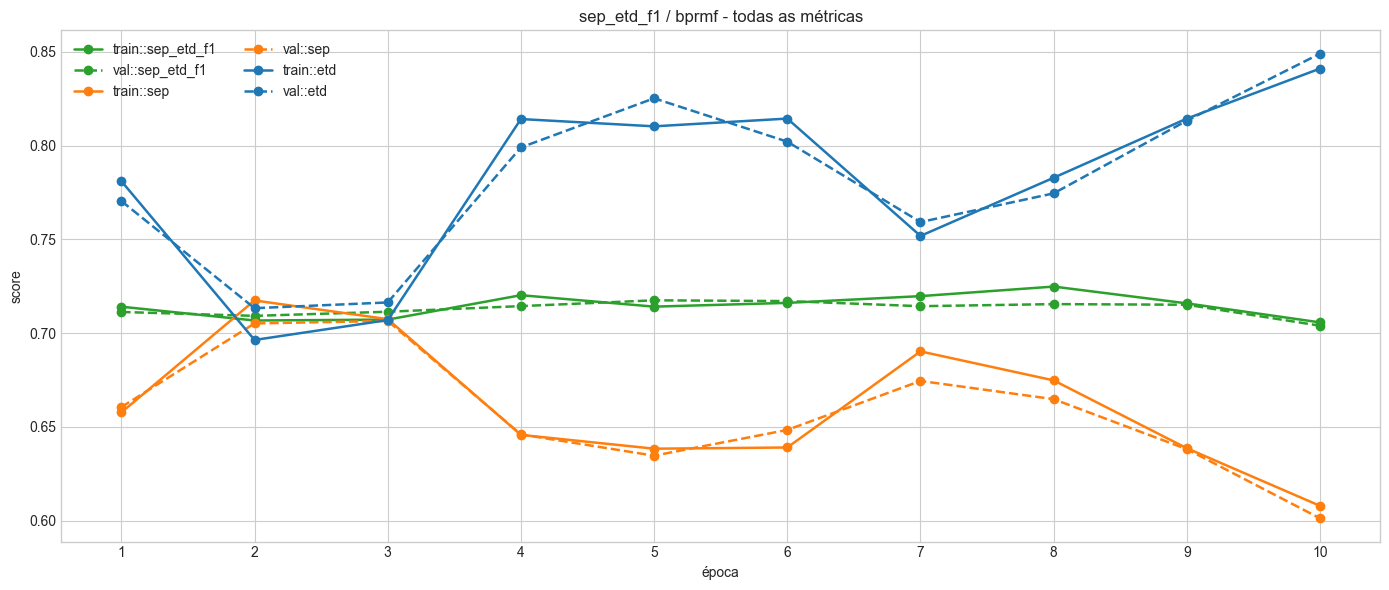

### ncf | repr=sbert | lambda=0.5

,process_dir_rel,objective_metric,algorithm,representation_model,mmr_lambda_quality,best_train_epoch,best_train_metric,best_val_epoch,best_val_metric,saved_best_origin
0,out/prompt_optimization/Llama3.1-I/ncf/sep_etd_f1/repr_sbert/early_false/mmr_lambda_0_5/mmr_pool_10/Llama3.1-I/prompt_opt/sep_etd_f1,sep_etd_f1,ncf,sbert,0.5,8,0.705866,6,0.704074,train


Linhas verticais: roxo = melhor época só em treino; rosa = melhor época só em validação; cinza = mesma época foi a melhor em treino e validação.

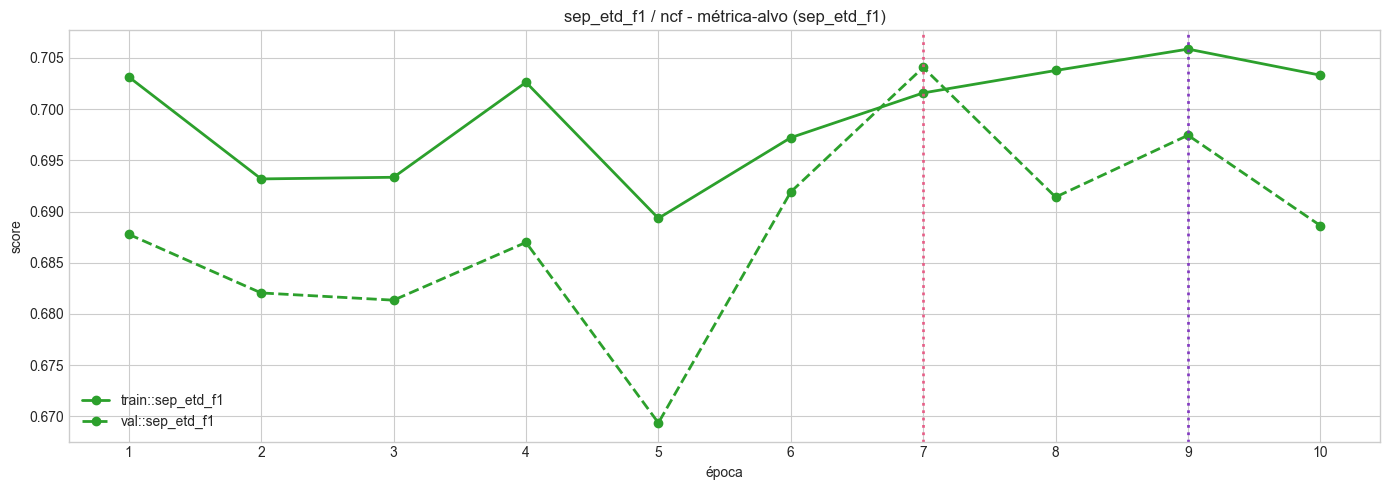

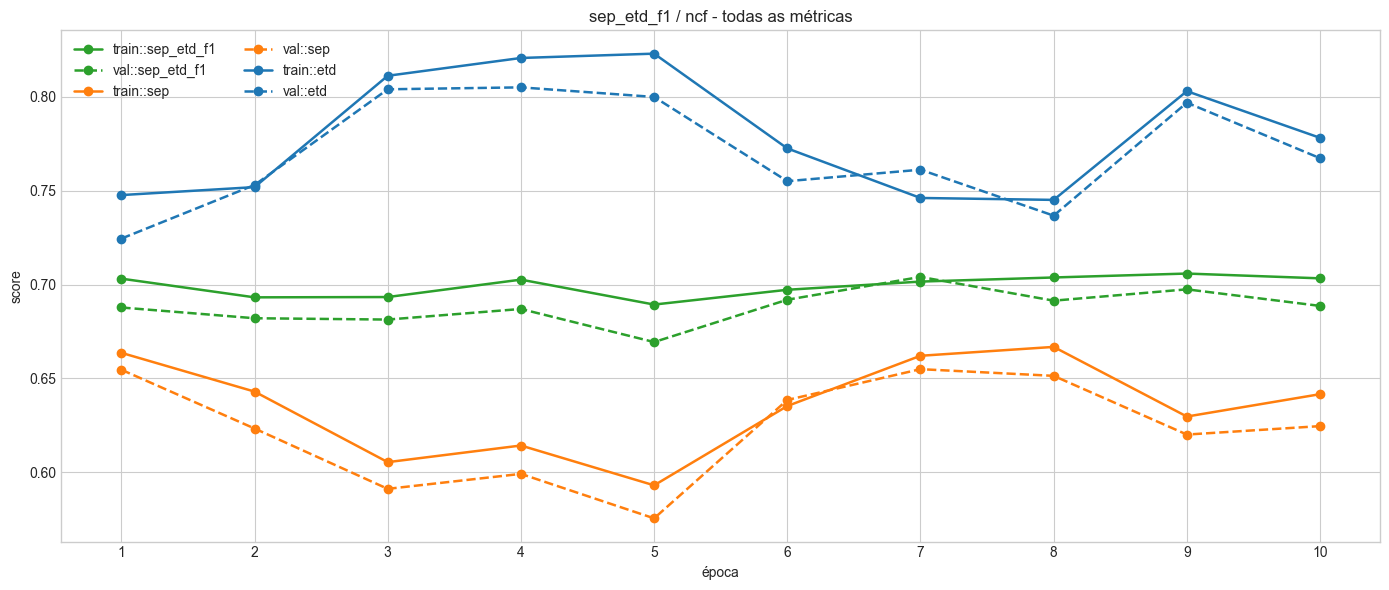

In [4]:
summary_df = load_summary(SUMMARY_CSV)

if summary_df.empty:
    warnings.warn("O resumo por usuário está vazio. Nenhum gráfico foi montado.")
else:
    display(Markdown(
        "Este notebook usa os mesmos `best_system_prompt` selecionados nas tabelas globais por objetivo."
    ))

    for objective_metric in OBJECTIVE_ORDER:
        best_df = pick_best_optimized_rows(summary_df, objective_metric)

        if best_df.empty:
            display(Markdown(f"## Objetivo `{objective_metric}`"))
            display(Markdown("> Nenhum processo otimizado foi encontrado para este objetivo."))
            continue

        display(Markdown(f"## Objetivo `{objective_metric}`"))
        display(Markdown("### Configurações selecionadas"))
        display(
            best_df[
                [
                    "algorithm",
                    "representation_model_label",
                    "mmr_lambda_quality",
                    "mean_sep_per_user",
                    "mean_etd_per_user",
                    "mean_sep_etd_f1_per_user",
                    "process_dir_rel",
                ]
            ].rename(
                columns={
                    "representation_model_label": "representation_model",
                    "mean_sep_per_user": "sep_value",
                    "mean_etd_per_user": "etd_value",
                    "mean_sep_etd_f1_per_user": "sep_etd_f1_value",
                }
            ).style.format(
                {
                    "sep_value": "{:.6f}",
                    "etd_value": "{:.6f}",
                    "sep_etd_f1_value": "{:.6f}",
                },
                na_rep="-",
            )
        )

        for row in best_df.itertuples(index=False):
            process_path = PROJECT_ROOT / row.process_dir_rel
            display(Markdown(
                "### "
                + str(row.algorithm)
                + " | repr="
                + str(row.representation_model_label)
                + " | lambda="
                + str(row.mmr_lambda_quality)
            ))

            if not process_path.exists():
                display(Markdown(f"> Processo não encontrado em `{row.process_dir_rel}`."))
                continue

            bundle = load_process_bundle(process_path, PROJECT_ROOT)
            display(
                pd.DataFrame(
                    [
                        {
                            "process_dir_rel": row.process_dir_rel,
                            "objective_metric": objective_metric,
                            "algorithm": row.algorithm,
                            "representation_model": row.representation_model_label,
                            "mmr_lambda_quality": row.mmr_lambda_quality,
                            "best_train_epoch": bundle["summary"]["best_train_epoch"],
                            "best_train_metric": bundle["summary"]["best_train_metric"],
                            "best_val_epoch": bundle["summary"]["best_val_epoch"],
                            "best_val_metric": bundle["summary"]["best_val_metric"],
                            "saved_best_origin": bundle["summary"]["saved_best_origin"],
                        }
                    ]
                )
            )

            draw_process_charts(
                bundle=bundle,
                title_prefix=f"{objective_metric} / {row.algorithm}",
            )
